# Time Dependency for Circuits

PyZX circuits describe *what* happens but not *when*. This notebook shows the
optional 1+1D time layer: give `to_graph` a `gate_durations` argument and every
spider is annotated with a `timestep` (when the gate starts) and a `delay`
(how long it takes). On top of that you get an as-soon-as-possible scheduler,
space-time cost metrics, a `time_slice` to cut out a window of the computation,
and a `show_time` drawing mode.

It is entirely opt-in: without `gate_durations` nothing changes, and a timed
graph is still an ordinary `GraphS` that every existing rule, extraction and
tensor routine handles unchanged. The last part of the notebook demonstrates
exactly that.

In [1]:
%matplotlib inline
import sys; sys.path.insert(0, '../..')  # use the local copy of pyzx
import random
from fractions import Fraction
import pyzx as zx

## A circuit to work with

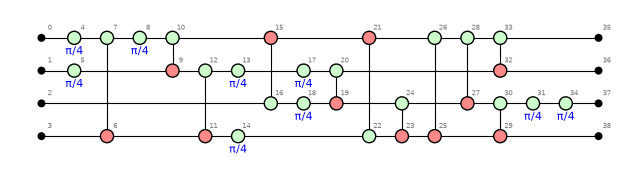

In [2]:
random.seed(42)
circ = zx.generate.CNOT_HAD_PHASE_circuit(qubits=4, depth=20)
zx.draw_matplotlib(circ, labels=True, h_edge_draw='box')

## Nothing changes unless you ask for it

`circ.to_graph()` with no `gate_durations` produces exactly the graph it always
did &mdash; no time data attached.

has_time_data: False


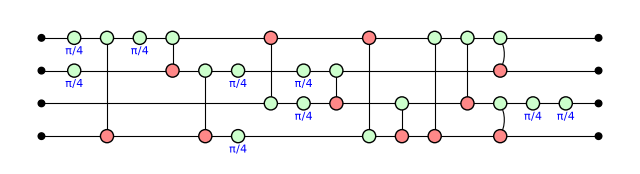

In [3]:
g_plain = circ.to_graph()
print("has_time_data:", zx.has_time_data(g_plain))
zx.draw_matplotlib(g_plain)

## Opting in: `gate_durations`

The keys are a gate class (`pyzx.circuit.gates.CNOT`) or a gate name (`"CNOT"`);
the value is a non-negative integer duration. A gate that appears in neither is
instantaneous (duration `0`), which draws exactly like stock PyZX. Passing `{}`
opts in with every gate instantaneous &mdash; a pure dependency layering.

has_time_data: True


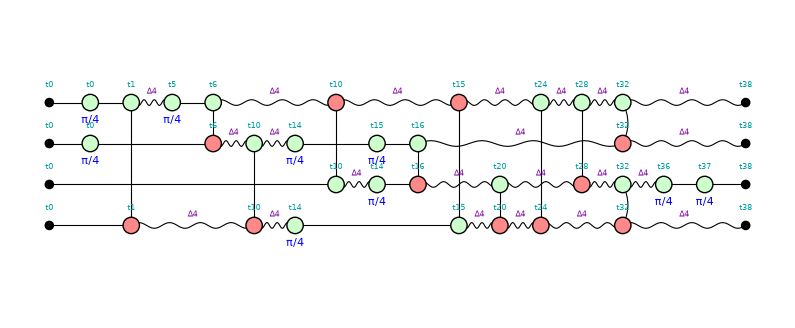

In [4]:
durations = {"CNOT": 4, "HAD": 1}
g = circ.to_graph(gate_durations=durations)
print("has_time_data:", zx.has_time_data(g))
zx.draw_matplotlib(g, show_time=True, figsize=(10, 4))

## The schedule

Gates are placed as soon as their qubits are free, so independent gates share a
timestep. `used_qubits` reports which qubits a gate touches; `schedule_gates`
returns `(timestep, delay)` per gate.

In [5]:
from pyzx.circuit.scheduling import schedule_gates, used_qubits

basic = circ.to_basic_gates()
sched = schedule_gates(basic.gates, durations)
for gate, (t, d) in list(zip(basic.gates, sched))[:12]:
    print(f"t={t:<3} delay={d:<2} {str(gate):<22} qubits={used_qubits(gate)}")

t=0   delay=0  T(0)                   qubits=[0]
t=0   delay=0  T(1)                   qubits=[1]
t=1   delay=4  CNOT(0,3)              qubits=[0, 3]
t=5   delay=0  T(0)                   qubits=[0]
t=6   delay=4  CNOT(0,1)              qubits=[0, 1]
t=10  delay=4  CNOT(1,3)              qubits=[1, 3]
t=14  delay=0  T(1)                   qubits=[1]
t=14  delay=0  T(3)                   qubits=[3]
t=10  delay=4  CNOT(2,0)              qubits=[0, 2]
t=15  delay=0  T(1)                   qubits=[1]
t=14  delay=0  T(2)                   qubits=[2]
t=16  delay=4  CNOT(1,2)              qubits=[1, 2]


## Per-spider attributes

`timestep` and `delay` are stored in the graph's vertex data. Read them with
`zx.get_timestep` / `zx.get_delay` (or `g.vdata(v, 'timestep')` directly).

In [6]:
print(f"{'vertex':>6} {'type':<9} {'qubit':>5} {'timestep':>9} {'delay':>6}")
for v in list(g.vertices())[:14]:
    print(f"{v:>6} {zx.VertexType(g.type(v)).name:<9} {g.qubit(v):>5} "
          f"{str(zx.get_timestep(g, v)):>9} {zx.get_delay(g, v):>6}")

vertex type      qubit  timestep  delay
     0 BOUNDARY      0         0      0
     1 BOUNDARY      1         0      0
     2 BOUNDARY      2         0      0
     3 BOUNDARY      3         0      0
     4 Z             0         0      0
     5 Z             1         0      0
     6 X             3         1      4
     7 Z             0         1      4
     8 Z             0         5      0
     9 X             1         6      4
    10 Z             0         6      4
    11 X             3        10      4
    12 Z             1        10      4
    13 Z             1        14      0


## Visualising time

`show_time=True` labels each timed spider `t<timestep>` and draws any wire whose
earlier spider has `delay > 0` as a squiggle labelled `Δ<delay>`. Instantaneous
wires are unchanged.

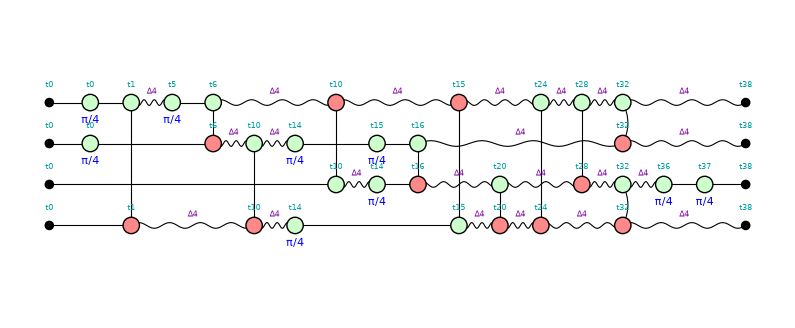

In [7]:
zx.draw_matplotlib(g, show_time=True, figsize=(10, 4))

## Space-time cost metrics

In [8]:
print(zx.spacetime_metrics(g))
print("time_extent:", zx.time_extent(g))

{'num_timesteps': 14, 'time_depth': 38, 'spacetime_volume': 97, 'total_delay': 88}
time_extent: (0, 37)


## A window of the computation: `time_slice`

`time_slice(g, start, stop)` returns the sub-diagram of spiders whose
`[timestep, timestep+delay]` interval meets the window. Edges crossing the cut
are closed off with fresh boundary vertices, so the result is a valid ZX-diagram
you can reason about on its own.

kept 12 vertices; inputs (0, 1, 2, 3) outputs (11, 9, 8, 10)


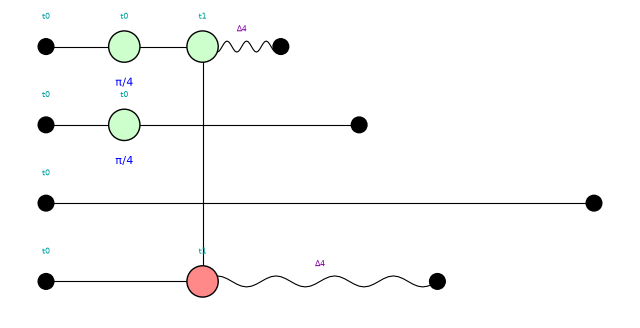

In [9]:
lo, hi = zx.time_extent(g)
window = zx.time_slice(g, lo, lo + 3)
print("kept", window.num_vertices(), "vertices;",
      "inputs", window.inputs(), "outputs", window.outputs())
zx.draw_matplotlib(window, show_time=True, figsize=(8, 4))

## It does not conflict with the rest of PyZX

A timed graph is an ordinary `GraphS`. Running a simplification on it gives the
same result as on the untimed graph, and extraction / tensors are unaffected.

In [10]:
timed   = circ.to_graph(gate_durations=durations)
untimed = circ.to_graph()

a = timed.copy();   zx.clifford_simp(a, quiet=True)
b = untimed.copy(); zx.clifford_simp(b, quiet=True)

print("same vertex count after clifford_simp:", a.num_vertices() == b.num_vertices())
print("same tensor:", zx.compare_tensors(a, b, preserve_scalar=False))

same vertex count after clifford_simp: True
same tensor: True


In [11]:
c_out = zx.extract_circuit(a.copy())
print("extracted circuit still equals the original:",
      zx.compare_tensors(c_out, circ, preserve_scalar=False))

extracted circuit still equals the original: True


## What happens to the annotation under rewriting

Simplification rules fuse spiders (the survivor keeps its own `timestep`, the
other is dropped) and create new spiders (no `timestep`). The annotation never
raises &mdash; `spacetime_metrics` skips untimed spiders, `time_slice` excludes
them &mdash; but it is only *meaningful* on a graph that still corresponds to a
scheduled circuit.

In [12]:
still_timed = sum(1 for v in a.vertices() if zx.get_timestep(a, v) is not None)
print(f"{still_timed} / {a.num_vertices()} spiders still carry a timestep "
      f"after full simplification")

16 / 16 spiders still carry a timestep after full simplification


Drawn with `show_time` and measured, **before** simplification (`timed`) and **after** `clifford_simp` (`a`). Fusion pulls the timeline together — fewer distinct timesteps and a smaller space-time volume — and here every surviving spider still carries a `timestep` (this circuit only fuses; a circuit whose rules create new spiders would leave some untimed, as noted above).

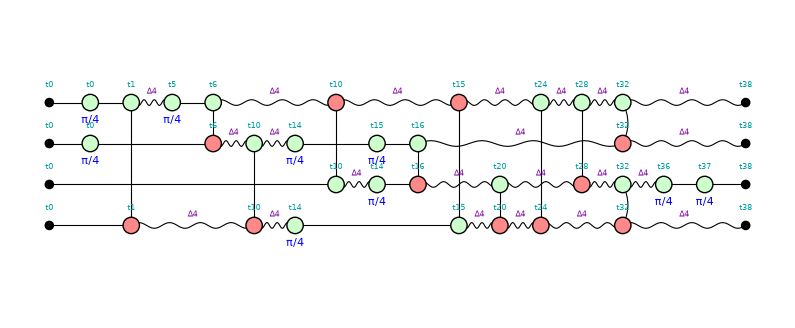

In [13]:
zx.draw_matplotlib(timed, show_time=True, figsize=(10, 4))

In [14]:
print(zx.spacetime_metrics(timed))
print("time_extent:", zx.time_extent(timed))

{'num_timesteps': 14, 'time_depth': 38, 'spacetime_volume': 97, 'total_delay': 88}
time_extent: (0, 37)


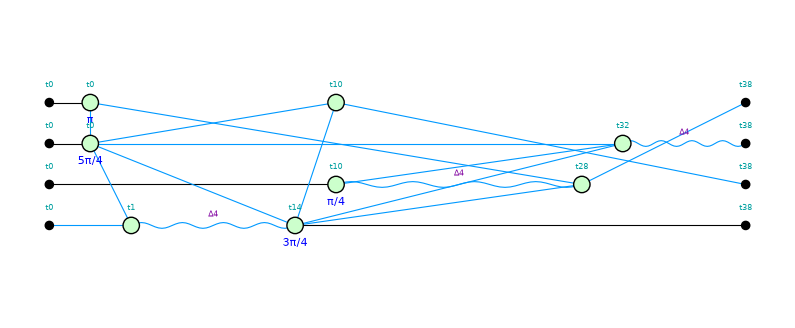

In [15]:
zx.draw_matplotlib(a, show_time=True, figsize=(10, 4))

In [16]:
print(zx.spacetime_metrics(a))
print("time_extent:", zx.time_extent(a))

{'num_timesteps': 6, 'time_depth': 37, 'spacetime_volume': 23, 'total_delay': 20}
time_extent: (0, 36)


## Recommended workflow

* annotate &rarr; inspect / slice / visualise / measure;
* to simplify, work on a `.copy()` and treat the result as untimed;
* `to_qasm()`, `to_tensor()` and `to_graph()` round-trips are all unaffected.

In [17]:
print(circ.to_basic_gates().to_qasm()[:300])

OPENQASM 2.0;
include "qelib1.inc";
qreg q[4];
t q[0];
t q[1];
cx q[0], q[3];
t q[0];
cx q[0], q[1];
cx q[1], q[3];
t q[1];
t q[3];
cx q[2], q[0];
t q[1];
t q[2];
cx q[1], q[2];
cx q[3], q[0];
cx q[2], q[3];
cx q[0], q[3];
cx q[0], q[2];
cx q[2], q[3];
t q[2];
cx q[0], q[1];
t q[2];



This concludes the time-dependency tutorial. For the rest of PyZX see the
[Getting Started notebook](gettingstarted.ipynb).